In [32]:
import sys
print(sys.executable)

%pip install -U pandas gprofiler-official ipykernel

/usr/local/bin/python3.10
Note: you may need to restart the kernel to use updated packages.


In [33]:

from gprofiler import GProfiler
import pandas as pd

gene_list = ["TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
"SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
"CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2"]

print(len(gene_list))
print(gene_list)

gp = GProfiler()
results = gp.profile(gene_list, organism="hsapiens", no_evidences=False) #no_evidences=False is set to show intersections
results = pd.DataFrame(results)
print(results.shape)

results.head()

23
['TP53', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'GADD45A', 'GADD45B', 'SESN1', 'SESN2', 'RRM2B', 'DRAM1', 'FAS', 'TNFRSF10B', 'APAF1', 'CASP3', 'CASP9', 'CYCS', 'PTEN', 'ATM', 'ATR', 'BRCA1', 'BRCA2']
(608, 16)


,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,p53 signaling pathway,8484,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,5.941134e-39,[KEGG:00000],0.909091,query_1,22,0.270270,True,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,8.715110e-36,[WP:000000],0.826087,query_1,23,0.275362,True,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
2,miRNA regulation of DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.994203e-35,[WP:000000],0.826087,query_1,23,0.260274,True,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
3,Platinum drug resistance,8484,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.175199e-20,[KEGG:00000],0.590909,query_1,22,0.180556,True,KEGG,72,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
4,miRNA regulation of p53 pathway in prostate ca...,8752,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.706305e-20,[WP:000000],0.478261,query_1,23,0.354839,True,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."


In [34]:
import sys
print(sys.executable)
!{sys.executable} -m pip install sentence-transformers scikit-learn

/usr/local/bin/python3.10


In [35]:
%pip install scipy
import sys
sys.path.append("/Users/abdulazizalshujaa/Desktop/CrossEnrich/src")

from crossenrich.standardization import (standardize_results_frame, split_by_source)

frame = standardize_results_frame(results)
columns = ["description", "name"]
#, "intersections", "name", "p_value", "canonical_source", "rank_within_source", "term_tokens", "standardized_name", "parent_terms"
#frame[columns].head()

#display(frame[columns].head(200))
line = frame.loc[196]
print("Name", line["name"])
print("Description", line["description"])
#dict_frame = split_by_source(frame)
#frame_source = pd.DataFrame()
#for source, frame in dict_frame.items():
 #   print(f"{source}")




Note: you may need to restart the kernel to use updated packages.
Name response to chemical
Description "Any process that results in a change in state or activity of a cell or an organism (in terms of movement, secretion, enzyme production, gene expression, etc.) as a result of a chemical stimulus." [GOC:jl]


In [37]:
import importlib
import crossenrich.semantic as semantic
importlib.reload(semantic)

from crossenrich.semantic import (build_semantic_similarity_matrix, cluster_terms, build_cluster_consistency_matrix)

semantic_similarity = frame.copy()
semantic_similarity = build_semantic_similarity_matrix(semantic_similarity, cross_source_only=False)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12722.80it/s]
BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
%pip install -U matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Term-term similarity matrix:


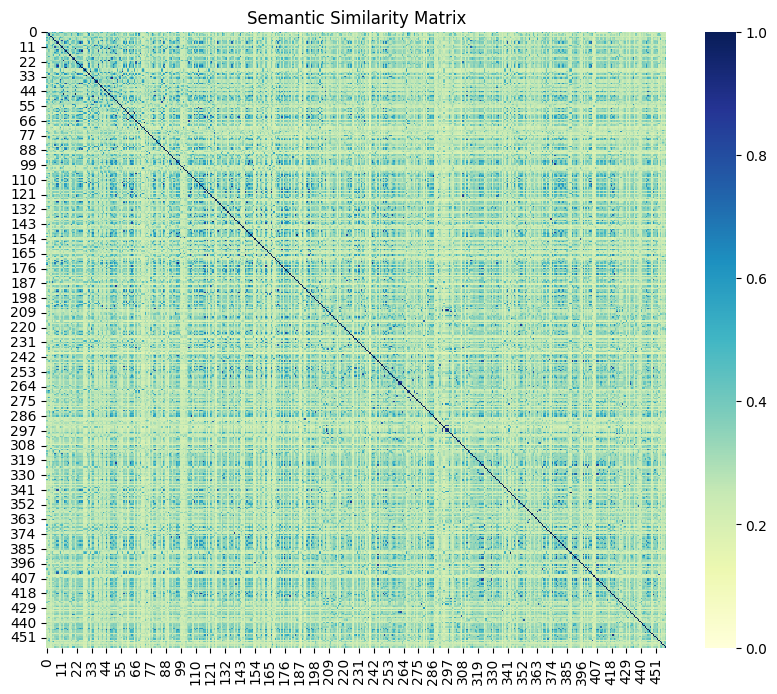

,0,1,2,3,4,5,6,7,8,9,...,449,450,451,452,453,454,455,456,457,458
0,1.00,0.35,0.35,0.31,0.55,0.38,0.50,0.28,0.27,0.49,...,0.27,0.26,0.27,0.24,0.25,0.27,0.26,0.25,0.25,0.25
1,0.35,1.00,0.76,0.31,0.30,0.34,0.30,0.39,0.38,0.31,...,0.20,0.24,0.27,0.33,0.45,0.26,0.26,0.25,0.24,0.24
2,0.35,0.76,1.00,0.29,0.51,0.46,0.31,0.36,0.36,0.32,...,0.28,0.24,0.26,0.38,0.41,0.36,0.25,0.25,0.26,0.24
3,0.31,0.31,0.29,1.00,0.31,0.27,0.27,0.25,0.25,0.27,...,0.21,0.25,0.24,0.21,0.21,0.25,0.23,0.22,0.22,0.22
4,0.55,0.30,0.51,0.31,1.00,0.41,0.39,0.30,0.29,0.40,...,0.33,0.30,0.28,0.33,0.26,0.37,0.25,0.27,0.28,0.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,0.27,0.26,0.36,0.25,0.37,0.51,0.26,0.29,0.28,0.29,...,0.30,0.27,0.28,0.33,0.22,1.00,0.36,0.29,0.39,0.37
455,0.26,0.26,0.25,0.23,0.25,0.25,0.23,0.24,0.23,0.26,...,0.22,0.20,0.23,0.24,0.23,0.36,1.00,0.26,0.36,0.43
456,0.25,0.25,0.25,0.22,0.27,0.23,0.30,0.28,0.27,0.23,...,0.25,0.26,0.28,0.27,0.21,0.29,0.26,1.00,0.33,0.30
457,0.25,0.24,0.26,0.22,0.28,0.26,0.27,0.26,0.26,0.26,...,0.24,0.25,0.27,0.26,0.21,0.39,0.36,0.33,1.00,0.37


In [39]:

import matplotlib.pyplot as plt
import seaborn as sns

print("Term-term similarity matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(semantic_similarity, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Matrix")
plt.show()
display(semantic_similarity.round(2))

In [40]:
import numpy as np
sim = semantic_similarity.copy()

print("min sim:", np.nanmin(sim.to_numpy()))
print("max sim:", np.nanmax(sim.to_numpy()))
print("any > 1:", (sim.to_numpy() > 1).any())
print("any NaN:", np.isnan(sim.to_numpy()).any())

min sim: 0.13088130719321117
max sim: 1.0
any > 1: False
any NaN: False


In [42]:
cluster = cluster_terms(frame, similarity_threshold=0.4, method="hierarchical")
cluster_consistency = build_cluster_consistency_matrix(cluster)

In [43]:
print("Clustered term table:")
display(
    cluster[[
        "canonical_source",
        "name",
        "standardized_name",
        "cluster_id",
        "cluster_label",
        "semantic_similarity_max",
    ]].sort_values(["cluster_id", "canonical_source"])
)

Clustered term table:


,canonical_source,name,standardized_name,cluster_id,cluster_label,semantic_similarity_max
328,GO:BP,development of primary female sexual character...,development of primary female sexual character...,0,development of primary female sexual character...,0.334247
405,WP,Peroxiredoxin 2 induced ovarian failure,peroxiredoxin 2 induced ovarian failure,1,peroxiredoxin 2 induced ovarian failure,0.318747
273,GO:BP,lymphocyte homeostasis,lymphocyte homeostasis,2,copper homeostasis,0.403087
246,WP,Copper homeostasis,copper homeostasis,2,copper homeostasis,0.403087
239,KEGG,Legionellosis,legionellosis,3,legionellosis,0.296915
...,...,...,...,...,...,...
250,GO:BP,negative regulation of G2/M transition of mito...,negative regulation of g2 m transition of mito...,329,negative regulation of g2 m transition of mito...,0.470818
69,GO:BP,signal transduction,signal transduction,330,signal transduction,0.420724
229,GO:BP,G2/M transition of mitotic cell cycle,g2 m transition of mitotic cell cycle,331,g2 m transition of mitotic cell cycle,0.480286
409,GO:BP,embryo development,embryo development,332,embryo development,0.378231


Database-level cluster consistency matrix:


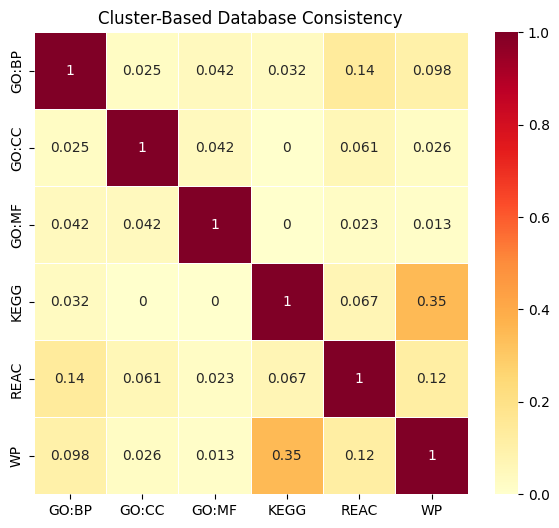

,GO:BP,GO:CC,GO:MF,KEGG,REAC,WP
GO:BP,1.00,0.02,0.04,0.03,0.14,0.10
GO:CC,0.02,1.00,0.04,0.00,0.06,0.03
GO:MF,0.04,0.04,1.00,0.00,0.02,0.01
KEGG,0.03,0.00,0.00,1.00,0.07,0.35
REAC,0.14,0.06,0.02,0.07,1.00,0.12
WP,0.10,0.03,0.01,0.35,0.12,1.00


In [44]:
print("Database-level cluster consistency matrix:")
plt.figure(figsize=(7, 6))
sns.heatmap(
    cluster_consistency,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Cluster-Based Database Consistency")
plt.show()
display(cluster_consistency.round(2))